Environmental Setup

In [ ]:
# Import libraries

import numpy as np
import tensorflow as tf
from tensorflow import keras
# import pandas as pd
import os
import shutil
import random
import glob
from os import listdir
from PIL import Image
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Flatten, BatchNormalization, Conv2D, MaxPool2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive

In [ ]:
# Mounting the drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Setting the base path
base_path =  "/content/gdrive/MyDrive/Deep Learning/"

In [ ]:
# Change the working directory to the base_path
os.chdir(base_path)


In [ ]:
# Set several parameters
IMAGE_SIZE = 256
BATCH_SIZE =10 
EPOCHS = 100

TRAIN_PATH = 'dataset2/train'
TEST_PATH = 'dataset2/test'

Task 2: Dataset Curation

In [ ]:
# Unzip the dataset
if os.path.isdir('dataset2') is False:
  !unzip -q dataset2.zip

In [ ]:
# Checking whether all files are images and they can be opened. 

images = []
for filename in os.listdir('dataset2'):
    try:
        img = mpimg.imread(os.path.join('dataset2', filename))
        if img is not None:
            images.append(img)
    except:
        print('Cant import ' + filename)
images = np.asarray(images)

Cant import cloudy
Cant import rain
Cant import shine
Cant import sunrise
Cant import train
Cant import test


In [ ]:
# Organize the data into directories

os.chdir('dataset2')

if os.path.isdir('cloudy') is False:
    os.makedirs('cloudy')
    os.makedirs('rain')
    os.makedirs('shine')
    os.makedirs('sunrise')

    for i in glob.glob('cloudy*'):
        shutil.move(i, 'cloudy')      
    for i in glob.glob('rain*'):
        shutil.move(i, 'rain')
    for i in glob.glob('shine*'):
        shutil.move(i, 'shine')      
    for i in glob.glob('sunrise*'):
        shutil.move(i, 'sunrise')

os.chdir('../')

In [ ]:
# Spliting data into training and testing sets and accoring to their class labels

rootdir= 'dataset2' #path of the original folder

classes = ['cloudy', 'rain', 'sunrise', 'shine']

#below steps will be performed if there is no previously created train directory 
if os.path.isdir('dataset2/train/cloudy') is False: 

  for i in classes:
    os.makedirs(rootdir +'/train/' + i)

    os.makedirs(rootdir +'/test/' + i)

    source = rootdir + '/' + i

    allFileNames = os.listdir(source)

    np.random.shuffle(allFileNames)

    test_ratio = 0.3

    train_FileNames, test_FileNames = np.split(np.array(allFileNames), [int(len(allFileNames)* (1 - test_ratio))])

    train_FileNames = [source+'/'+ name for name in train_FileNames.tolist()]
    test_FileNames = [source+'/' + name for name in test_FileNames.tolist()]

    for name in train_FileNames:
      shutil.copy(name, rootdir +'/train/' + i)

    for name in test_FileNames:
      shutil.copy(name, rootdir +'/test/' + i)

In [ ]:
# Data Generator
datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255,
                                                         )

train_gen = datagen.flow_from_directory(directory = TRAIN_PATH,
                                        batch_size = BATCH_SIZE,
                                        seed = 1,
                                        color_mode = 'rgb',
                                        shuffle = True,
                                        classes=classes,
                                        #class_mode = 'binary',
                                        target_size = (IMAGE_SIZE, IMAGE_SIZE))

test_gen = datagen.flow_from_directory(directory = TEST_PATH,
                                       batch_size = BATCH_SIZE, 
                                       seed = 1,
                                       color_mode = 'rgb',
                                       shuffle = True,
                                       classes=classes,
                                       #class_mode = 'binary',
                                       target_size = (IMAGE_SIZE, IMAGE_SIZE))

Found 786 images belonging to 4 classes.
Found 339 images belonging to 4 classes.


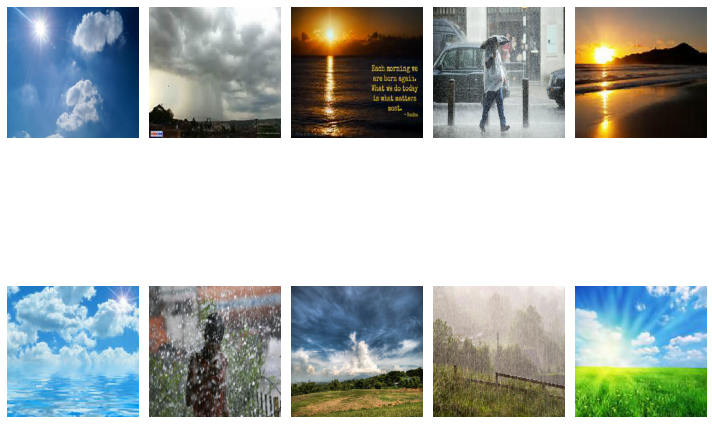

[[0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]


In [ ]:
# Ploting Images - 10 Training samples
images, labels = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize = (10, 10))

axes = axes.flatten()

for img, ax in zip(images, axes):
    ax.imshow(img.reshape(IMAGE_SIZE, IMAGE_SIZE, 3))
    ax.axis('off')
plt.tight_layout()
plt.show()
print(labels)


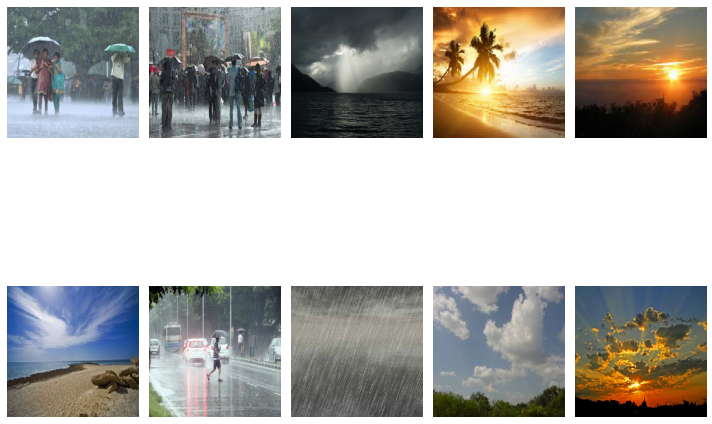

[[0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]


In [ ]:
# Ploting Images - 10 Testing samples
images, labels = next(test_gen)
fig, axes = plt.subplots(2, 5, figsize = (10, 10))

axes = axes.flatten()

for img, ax in zip(images, axes):
    ax.imshow(img.reshape(IMAGE_SIZE, IMAGE_SIZE, 3))
    ax.axis('off')

plt.tight_layout()
plt.show()
print(labels)

Task 3: Model Building

In [ ]:
# Build the CNN model
model = Sequential([
    Conv2D(filters=8, kernel_size=(3, 3), activation='relu', padding = 'same', input_shape=(256,256,3)),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding = 'same'),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding = 'same'),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding = 'same'),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding = 'same'),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Flatten(),
    Dense(units=4, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_29 (Conv2D)          (None, 256, 256, 8)       224       
                                                                 
 max_pooling2d_29 (MaxPoolin  (None, 128, 128, 8)      0         
 g2D)                                                            
                                                                 
 conv2d_30 (Conv2D)          (None, 128, 128, 16)      1168      
                                                                 
 max_pooling2d_30 (MaxPoolin  (None, 64, 64, 16)       0         
 g2D)                                                            
                                                                 
 conv2d_31 (Conv2D)          (None, 64, 64, 32)        4640      
                                                                 
 max_pooling2d_31 (MaxPoolin  (None, 32, 32, 32)      

In [ ]:
# Model Compile
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Set training and testing step sizes
STEP_SIZE_TRAIN = train_gen.n // BATCH_SIZE
STEP_SIZE_TEST = test_gen.n // BATCH_SIZE

In [ ]:
# Model training

history_ori = model.fit(
    x=train_gen,
    steps_per_epoch=STEP_SIZE_TRAIN,
    validation_data=test_gen,
    validation_steps=STEP_SIZE_TEST,
    epochs=EPOCHS,
    verbose=2
)

# history = model.fit(X_train, y_train, nb_epoch=10, validation_data=(X_test, y_test), shuffle=True)

Epoch 1/100
78/78 - 42s - loss: 1.2339 - accuracy: 0.4523 - val_loss: 0.9322 - val_accuracy: 0.6091 - 42s/epoch - 536ms/step
Epoch 2/100
78/78 - 41s - loss: 0.6995 - accuracy: 0.7332 - val_loss: 0.6635 - val_accuracy: 0.7939 - 41s/epoch - 522ms/step
Epoch 3/100
78/78 - 41s - loss: 0.5378 - accuracy: 0.8080 - val_loss: 0.6406 - val_accuracy: 0.8030 - 41s/epoch - 520ms/step
Epoch 4/100
78/78 - 40s - loss: 0.5134 - accuracy: 0.8106 - val_loss: 0.6064 - val_accuracy: 0.7879 - 40s/epoch - 518ms/step
Epoch 5/100
78/78 - 40s - loss: 0.4894 - accuracy: 0.8247 - val_loss: 0.6462 - val_accuracy: 0.7939 - 40s/epoch - 517ms/step
Epoch 6/100
78/78 - 40s - loss: 0.4317 - accuracy: 0.8505 - val_loss: 0.5424 - val_accuracy: 0.8152 - 40s/epoch - 518ms/step
Epoch 7/100
78/78 - 41s - loss: 0.4099 - accuracy: 0.8570 - val_loss: 0.6118 - val_accuracy: 0.7727 - 41s/epoch - 520ms/step
Epoch 8/100
78/78 - 41s - loss: 0.3884 - accuracy: 0.8660 - val_loss: 0.5369 - val_accuracy: 0.8303 - 41s/epoch - 521ms/step


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])
Train Acc: 1.000, Test Acc: 0.926
Train Loss: 0.004, Test Loss: 0.564


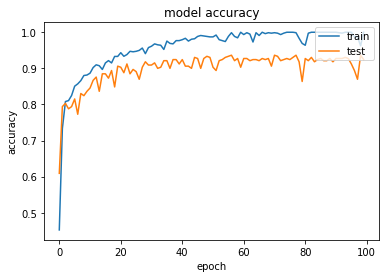

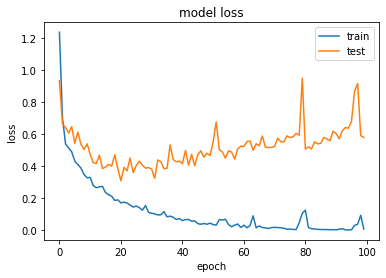

In [ ]:
# list all data in history
print(history_ori.history.keys())

# evaluate the model
train_loss, train_acc = model.evaluate(train_gen, verbose=0)
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print('Train Acc: %.3f, Test Acc: %.3f' % (train_acc, test_acc))
print('Train Loss: %.3f, Test Loss: %.3f' % (train_loss, test_loss))

#summarize history for accuracy 
plt.plot(history_ori.history['accuracy'])
plt.plot(history_ori.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

#summarize history for loss
plt.plot(history_ori.history['loss'])
plt.plot(history_ori.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

Task 3 - C : Attribute Regularization





In [1]:
# Generate augmented data
datagen1 = tf.keras.preprocessing.image.ImageDataGenerator(
                                                          rotation_range=10,
                                                          height_shift_range=0.2,
                                                          width_shift_range=0.2,
                                                          rescale=1./255,
                                                          shear_range=0.2,
                                                          zoom_range=0.2,
                                                          horizontal_flip=True,
                                                          preprocessing_function = None
                                                         )

train_gen1 = datagen1.flow_from_directory(directory = TRAIN_PATH,
                                        batch_size = BATCH_SIZE,
                                        seed = 1,
                                        color_mode = 'rgb',
                                        shuffle = True,
                                        classes=classes,
                                        target_size = (IMAGE_SIZE, IMAGE_SIZE))

test_gen1 = datagen1.flow_from_directory(directory = TEST_PATH,
                                       batch_size = BATCH_SIZE, 
                                       seed = 1,
                                       color_mode = 'rgb',
                                       shuffle = True,
                                       classes=classes,
                                       target_size = (IMAGE_SIZE, IMAGE_SIZE))

NameError: ignored

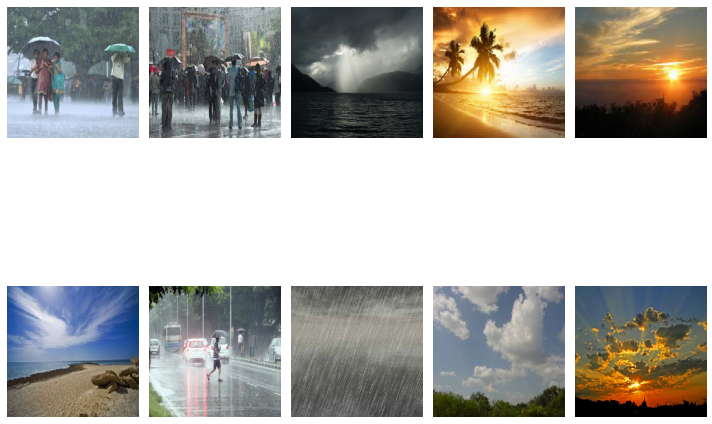

[[0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]


In [ ]:
# Ploting Images - 10 Testing samples
images, labels = next(test_gen1)
fig, axes = plt.subplots(2, 5, figsize = (10, 10))

axes = axes.flatten()

for img, ax in zip(images, axes):
    ax.imshow(img.reshape(IMAGE_SIZE, IMAGE_SIZE, 3))
    ax.axis('off')

plt.tight_layout()
plt.show()
print(labels)

In [ ]:
STEP_SIZE_TRAIN = train_gen1.n // BATCH_SIZE
STEP_SIZE_TEST = test_gen1.n // BATCH_SIZE

In [ ]:
# Model Training with augmented dataset
history1 = model.fit(
    x=train_gen1,
    steps_per_epoch=STEP_SIZE_TRAIN,
    validation_data=test_gen1,
    validation_steps=STEP_SIZE_TEST,
    epochs=EPOCHS,
    verbose=2
)


Epoch 1/100
78/78 - 50s - loss: 0.3777 - accuracy: 0.8930 - val_loss: 0.4667 - val_accuracy: 0.9212 - 50s/epoch - 647ms/step
Epoch 2/100
78/78 - 50s - loss: 0.2866 - accuracy: 0.9214 - val_loss: 0.3667 - val_accuracy: 0.9273 - 50s/epoch - 647ms/step
Epoch 3/100
78/78 - 50s - loss: 0.2242 - accuracy: 0.9240 - val_loss: 0.3198 - val_accuracy: 0.9242 - 50s/epoch - 645ms/step
Epoch 4/100
78/78 - 50s - loss: 0.1848 - accuracy: 0.9343 - val_loss: 0.3498 - val_accuracy: 0.9303 - 50s/epoch - 644ms/step
Epoch 5/100
78/78 - 50s - loss: 0.2359 - accuracy: 0.9098 - val_loss: 0.3519 - val_accuracy: 0.9212 - 50s/epoch - 644ms/step
Epoch 6/100
78/78 - 50s - loss: 0.2348 - accuracy: 0.9072 - val_loss: 0.3390 - val_accuracy: 0.9333 - 50s/epoch - 643ms/step
Epoch 7/100
78/78 - 50s - loss: 0.2147 - accuracy: 0.9227 - val_loss: 0.2952 - val_accuracy: 0.9273 - 50s/epoch - 645ms/step
Epoch 8/100
78/78 - 50s - loss: 0.1679 - accuracy: 0.9381 - val_loss: 0.3088 - val_accuracy: 0.9303 - 50s/epoch - 642ms/step


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])
Train Acc: 0.973, Test Acc: 0.932
Train Loss: 0.079, Test Loss: 0.281


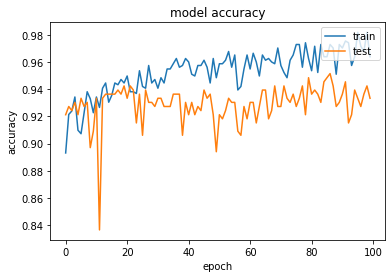

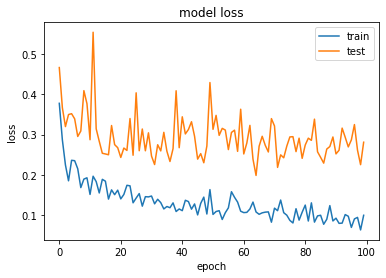

In [ ]:
# list all data in history
print(history1.history.keys())

# evaluate the model
train_loss, train_acc = model.evaluate(train_gen1, verbose=0)
test_loss, test_acc = model.evaluate(test_gen1, verbose=0)
print('Train Acc: %.3f, Test Acc: %.3f' % (train_acc, test_acc))
print('Train Loss: %.3f, Test Loss: %.3f' % (train_loss, test_loss))

#summarize history for accuracy 
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

#summarize history for loss
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

Task 3 - d : Model Regularization





In [ ]:
earlystopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_accuracy',
                                                 min_delta = 1e-3,
                                                 patience = 3,
                                                 mode = 'max',
                                                 restore_best_weights = True,
                                                 verbose = 2)

callbacks = [earlystopping]

In [ ]:
# Model Training with augmented dataset and early stoping
history2 = model.fit(
    x=train_gen1,
    steps_per_epoch=STEP_SIZE_TRAIN,
    validation_data=test_gen1,
    validation_steps=STEP_SIZE_TEST,
    epochs=EPOCHS,
    verbose=2,
    callbacks = callbacks
)

Epoch 1/100
78/78 - 50s - loss: 0.0748 - accuracy: 0.9729 - val_loss: 0.2574 - val_accuracy: 0.9424 - 50s/epoch - 647ms/step
Epoch 2/100
78/78 - 50s - loss: 0.0837 - accuracy: 0.9691 - val_loss: 0.3183 - val_accuracy: 0.9242 - 50s/epoch - 643ms/step
Epoch 3/100
78/78 - 50s - loss: 0.0757 - accuracy: 0.9729 - val_loss: 0.2159 - val_accuracy: 0.9364 - 50s/epoch - 641ms/step
Epoch 4/100
Restoring model weights from the end of the best epoch: 1.
78/78 - 50s - loss: 0.1145 - accuracy: 0.9536 - val_loss: 0.2352 - val_accuracy: 0.9333 - 50s/epoch - 646ms/step
Epoch 4: early stopping


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])
Train Acc: 0.976, Test Acc: 0.941
Train Loss: 0.074, Test Loss: 0.255


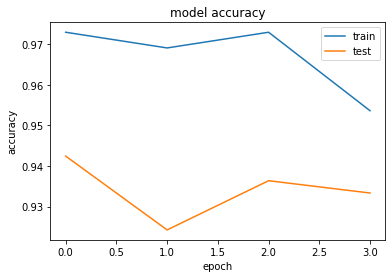

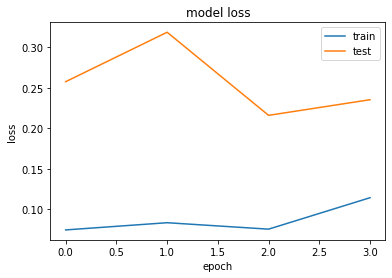

In [ ]:
# list all data in history
print(history2.history.keys())

# evaluate the model
train_loss, train_acc = model.evaluate(train_gen1, verbose=0)
test_loss, test_acc = model.evaluate(test_gen1, verbose=0)
print('Train Acc: %.3f, Test Acc: %.3f' % (train_acc, test_acc))
print('Train Loss: %.3f, Test Loss: %.3f' % (train_loss, test_loss))

#summarize history for accuracy 
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

#summarize history for loss
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [ ]:
# Develop a new model for experiementing with model hyperparamaters

model_new = Sequential([
    Conv2D(filters=8, kernel_size=(3, 3), activation='relu', padding = 'same', input_shape=(256,256,3)),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding = 'same'),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding = 'same'),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding = 'same'),
    BatchNormalization(axis=1),
    MaxPool2D(pool_size=(2, 2), strides=2),
    Flatten(),
    Dense(units=4, activation='softmax')
])



In [ ]:
model_new.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_34 (Conv2D)          (None, 256, 256, 8)       224       
                                                                 
 max_pooling2d_34 (MaxPoolin  (None, 128, 128, 8)      0         
 g2D)                                                            
                                                                 
 conv2d_35 (Conv2D)          (None, 128, 128, 16)      1168      
                                                                 
 max_pooling2d_35 (MaxPoolin  (None, 64, 64, 16)       0         
 g2D)                                                            
                                                                 
 conv2d_36 (Conv2D)          (None, 64, 64, 32)        4640      
                                                                 
 max_pooling2d_36 (MaxPoolin  (None, 32, 32, 32)      

In [ ]:
# New Model Compile
model_new.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# New Model Training 
history3 = model_new.fit(
    x=train_gen1,
    steps_per_epoch=STEP_SIZE_TRAIN,
    validation_data=test_gen1,
    validation_steps=STEP_SIZE_TEST,
    epochs=EPOCHS,
    verbose=2,
    callbacks = callbacks
)

Epoch 1/100
78/78 - 51s - loss: 1.3641 - accuracy: 0.3943 - val_loss: 1.3617 - val_accuracy: 0.5121 - 51s/epoch - 648ms/step
Epoch 2/100
78/78 - 50s - loss: 0.9501 - accuracy: 0.6379 - val_loss: 1.3100 - val_accuracy: 0.6939 - 50s/epoch - 638ms/step
Epoch 3/100
78/78 - 49s - loss: 0.7761 - accuracy: 0.7371 - val_loss: 1.2289 - val_accuracy: 0.7455 - 49s/epoch - 632ms/step
Epoch 4/100
78/78 - 49s - loss: 0.6981 - accuracy: 0.7500 - val_loss: 1.1205 - val_accuracy: 0.8061 - 49s/epoch - 634ms/step
Epoch 5/100
78/78 - 49s - loss: 0.6342 - accuracy: 0.7771 - val_loss: 0.9789 - val_accuracy: 0.8000 - 49s/epoch - 634ms/step
Epoch 6/100
78/78 - 49s - loss: 0.6049 - accuracy: 0.7642 - val_loss: 0.8342 - val_accuracy: 0.8242 - 49s/epoch - 634ms/step
Epoch 7/100
78/78 - 49s - loss: 0.5610 - accuracy: 0.8003 - val_loss: 0.6912 - val_accuracy: 0.8394 - 49s/epoch - 630ms/step
Epoch 8/100
78/78 - 49s - loss: 0.5440 - accuracy: 0.8015 - val_loss: 0.6145 - val_accuracy: 0.8515 - 49s/epoch - 631ms/step


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])
Train Acc: 0.835, Test Acc: 0.870
Train Loss: 0.469, Test Loss: 0.502


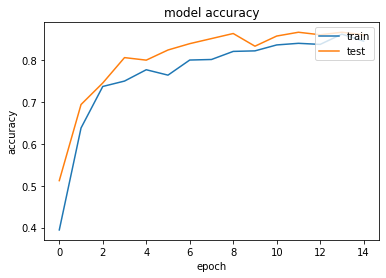

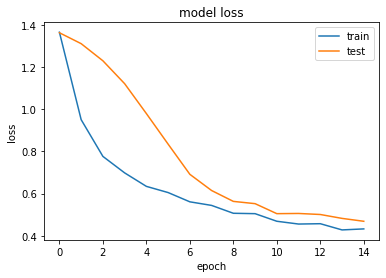

In [ ]:
# list all data in history
print(history3.history.keys())

# evaluate the model
train_loss, train_acc = model_new.evaluate(train_gen1, verbose=0)
test_loss, test_acc = model_new.evaluate(test_gen1, verbose=0)
print('Train Acc: %.3f, Test Acc: %.3f' % (train_acc, test_acc))
print('Train Loss: %.3f, Test Loss: %.3f' % (train_loss, test_loss))

#summarize history for accuracy 
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

#summarize history for loss
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()